## House Price Prediction using Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('train.csv')
print("First 5 Rows of the Dataset:")
df.head()

First 5 Rows of the Dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print("total number of rows and columns in the dataset:", df.shape)

total number of rows and columns in the dataset: (1460, 81)


In [4]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18

In [5]:
#sort the missing values in descending order so that we can see the columns with the most missing values at the top 
print("Missing Values in Each Column:")
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values.head(20)

Missing Values in Each Column:


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

In [6]:
# columns where missing means the feature doesn't exist
cols_fill_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu','GarageType', 'GarageFinish', 'GarageQual', 'GarageCond','BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2','MasVnrType']

for col in cols_fill_none:
    df[col] = df[col].fillna('None')

In [7]:
#sort the missing values in descending order so that we can see the columns with the most missing values at the top 
missing_values = df.isnull().sum().sort_values(ascending=False)
print("Columns with Missing Values:")
missing_values.head(10)

Columns with Missing Values:


LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
Electrical       1
Id               0
Street           0
MSSubClass       0
MSZoning         0
LotArea          0
Utilities        0
dtype: int64

In [8]:
# Fill in the missing values
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [9]:
# double sum to get the total number of missing values in the entire dataframe
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [10]:
# Split the dataset into features (X) and target (y)
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [11]:
X = pd.get_dummies(X, drop_first=True)

In [12]:
print("total number of rows and columns in the features dataset:", X.shape)

total number of rows and columns in the features dataset: (1460, 260)


In [13]:
#sklearn train_test_split function to split the data into training and testing sets
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
print("Training set size:\n rows\t column\n", X_train.shape[0],"\t",X_train.shape[1])
print("Testing set size:\n rows\t column\n", X_test.shape[0],"\t",X_test.shape[1])

Training set size:
 rows	 column
 1168 	 260
Testing set size:
 rows	 column
 292 	 260


In [16]:
#import the linear regression model from sklearn
from sklearn.linear_model import LinearRegression

In [17]:
#create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](260,)","[ 0.34, -87.64, -128.8 ,..., 6295.5 , 7867.62,18948.26]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](260,)","['Id','MSSubClass','LotFrontage',...,'SaleCondition_Family', 'SaleCondition_Normal','SaleCondition_Partial']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.068e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,260
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,240


In [18]:
#predict the sales price by using test data to evaluate the model
y_pred = model.predict(X_test)

In [19]:
#import metrics to evaluate the model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 20282.010783999463


In [21]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 1107892535.3363707


In [22]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 33285.01968358094


In [23]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.855561223159157


**Results:** The model achieved an R² score of 0.86, which means it explains about 86% of the variation in house sale prices. The MAE is around $20,000, so on average the predicted price differs from the actual price by about $20,000. Since the RMSE ($33,000) is noticeably higher than the MAE, it suggests that a few houses have much larger prediction errors, likely because of outliers or properties with unusual characteristics.

## Actual vs Predicted plot

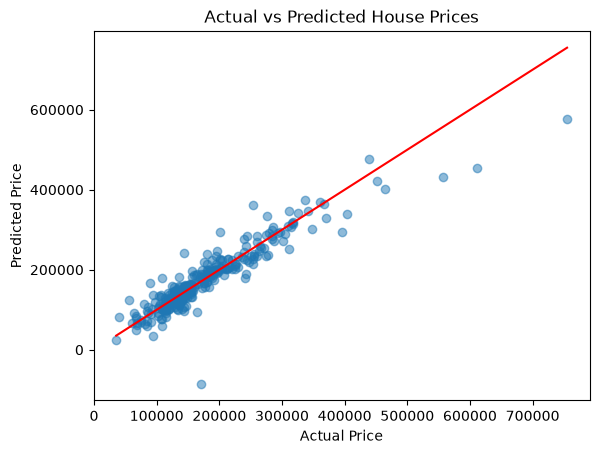

In [24]:
# scatter plot to visualize the actual vs predicted house prices and add a line representing perfect predictions
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')  # perfect prediction line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()

**Explanation:** Most points for lower-priced houses (under 300k) lie close to the red line, showing that the model predicts these houses fairly well. For more expensive houses (above 400k), the points are more scattered and generally fall below the red line, indicating that the model has more difficulty predicting high-priced houses and often underestimates their values. There is also one clear outlier around an actual price of 170k where the model predicted a negative house price, which is unrealistic and shows that it performed very poorly for that particular house.